# Pool Ball Detection - Task 1

## Step 1: Initialization and Data Loading
This section imports the allowed libraries and loads the pool table images specified in the input JSON file.

### 1.1 Load Libraries

In [3]:
import json
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt


### 1.2 Data Ingestion
Reads the JSON input and loads images into a dictionary, converting them to RGB.

In [4]:
json_file = "input.json" 
loaded_images = {}

with open(json_file, 'r') as f:
    data = json.load(f)

image_list = data.get("image_path", []) if isinstance(data, dict) else data

for full_path in image_list:
    img_bgr = cv2.imread(full_path)
    
    if img_bgr is not None:
        clean_name = os.path.basename(full_path)
        
        loaded_images[clean_name] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(loaded_images)} images.")

Loaded 50 images.


### 1.3 Sanity Check
Displays 3 random images to verify everything loaded correctly.

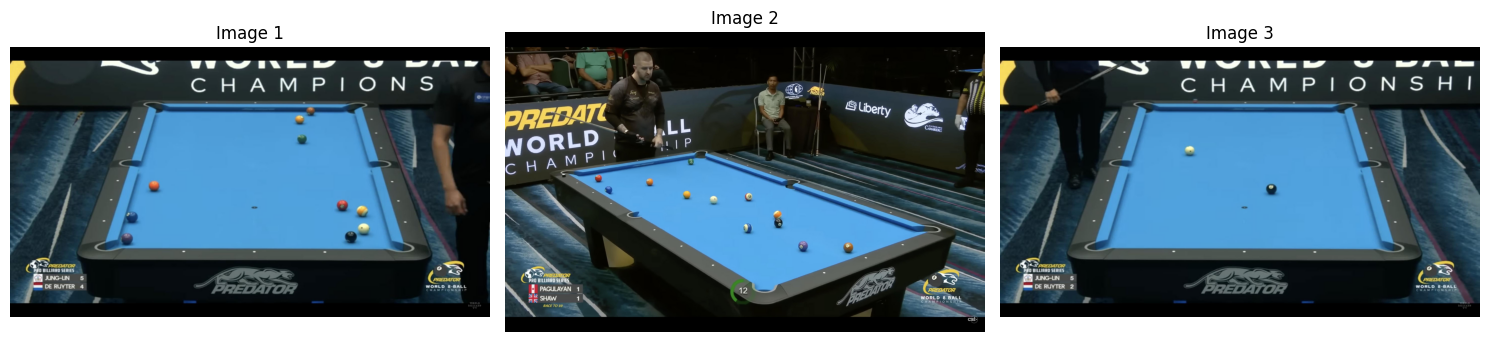

In [5]:
image_paths = list(loaded_images.keys())

first_three_images = image_paths[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
i = 1
for ax, key in zip(axes, first_three_images):
    ax.imshow(loaded_images[key])
    ax.set_title(f"Image {i}", color='black')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.show()

### 1.4 Define Test Image Variable

In [6]:
test_key = random.choice(image_paths)  
test_img = loaded_images[test_key]

## Step 2: Top Down View

### 2.1 Table Area Detection
To warp the image, we first need to isolate the playing surface from the background. Instead of hardcoding colors, this function dynamically samples the color at the center of the image. It then uses computer vision techniques (dilation, convex hulls, and erosion) to swallow up the pool balls, straighten the pocket edges, and output a clean, solid mask of just the playable area.


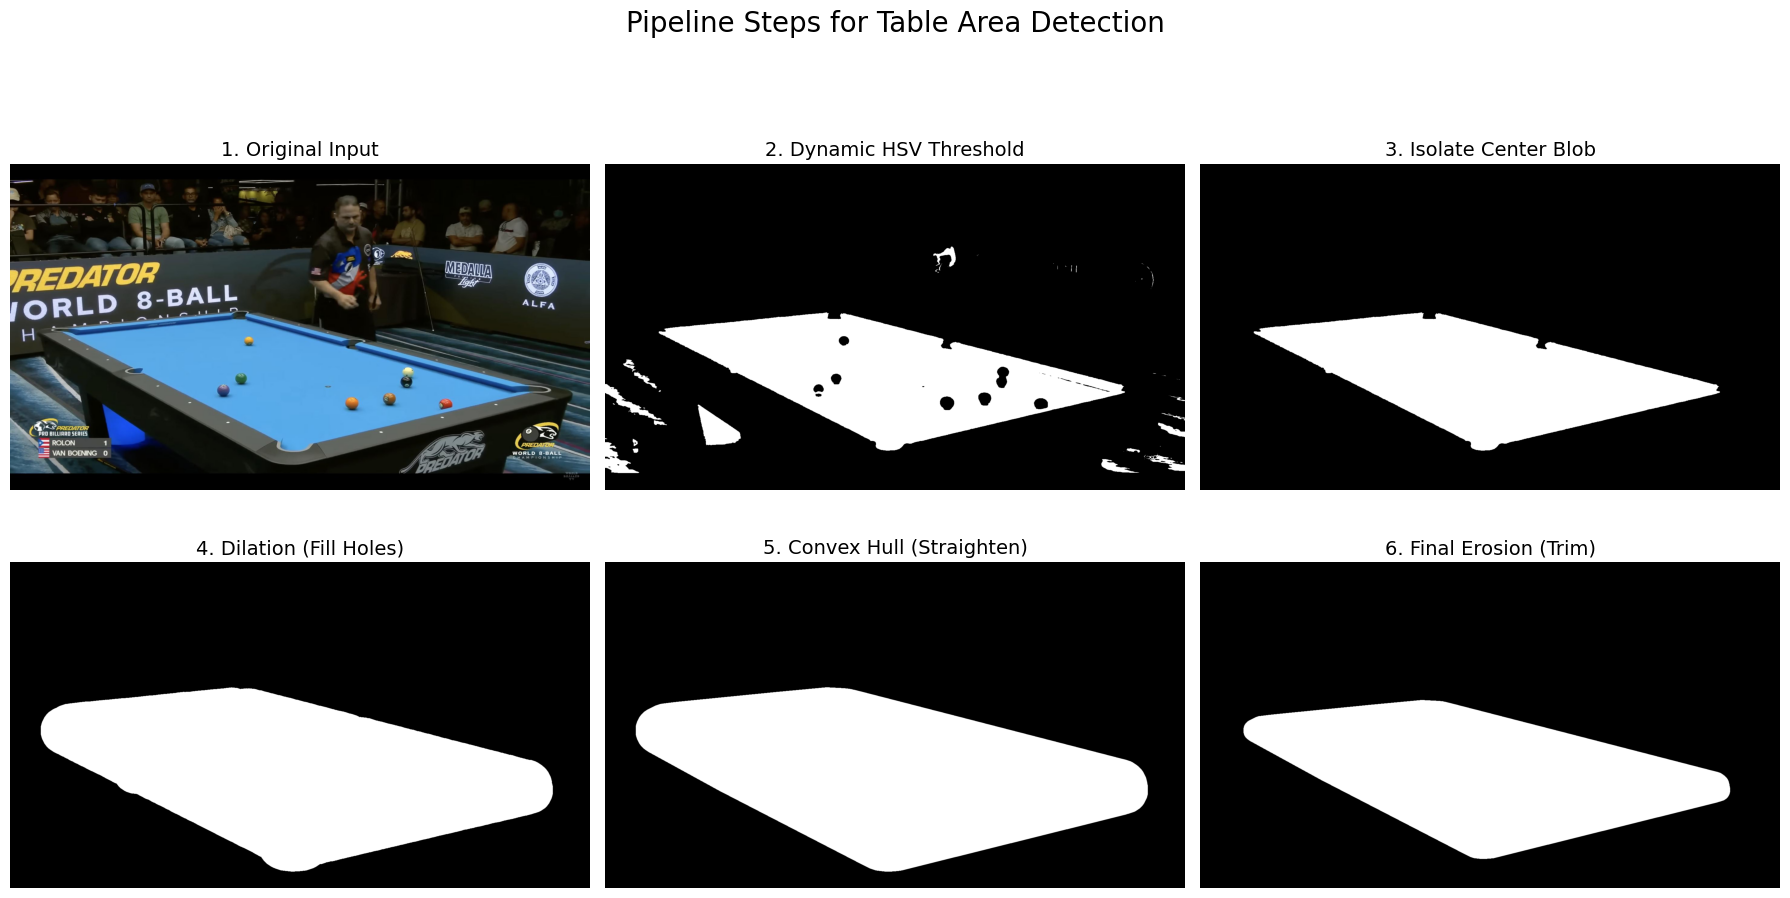

In [7]:
mask_steps = {}
# Function to get the table area
def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.020))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=2)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

# ═══════════════════════════════════════════════════════════════
#  Visualization Pipeline
# ═══════════════════════════════════════════════════════════════

final_mask = get_table_mask(test_img)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel() 

step_keys = sorted(mask_steps.keys())

titles = [
    "1. Original Input",
    "2. Dynamic HSV Threshold",
    "3. Isolate Center Blob",
    "4. Dilation (Fill Holes)",
    "5. Convex Hull (Straighten)",
    "6. Final Erosion (Trim)"
]

for i in range(len(step_keys)):
    key = step_keys[i]
    display_img = mask_steps[key]
    
    if len(display_img.shape) == 3: 
        axes[i].imshow(display_img)
    else: 
        axes[i].imshow(display_img, cmap='gray')
        
    axes[i].set_title(titles[i], color='black', fontsize=14)
    axes[i].axis('off') 

plt.suptitle("Pipeline Steps for Table Area Detection", fontsize=20, color='black')
plt.tight_layout(rect=[0, 0.01, 1, 0.96]) 
plt.show()


### 2.1.1 Check Mask Overlay

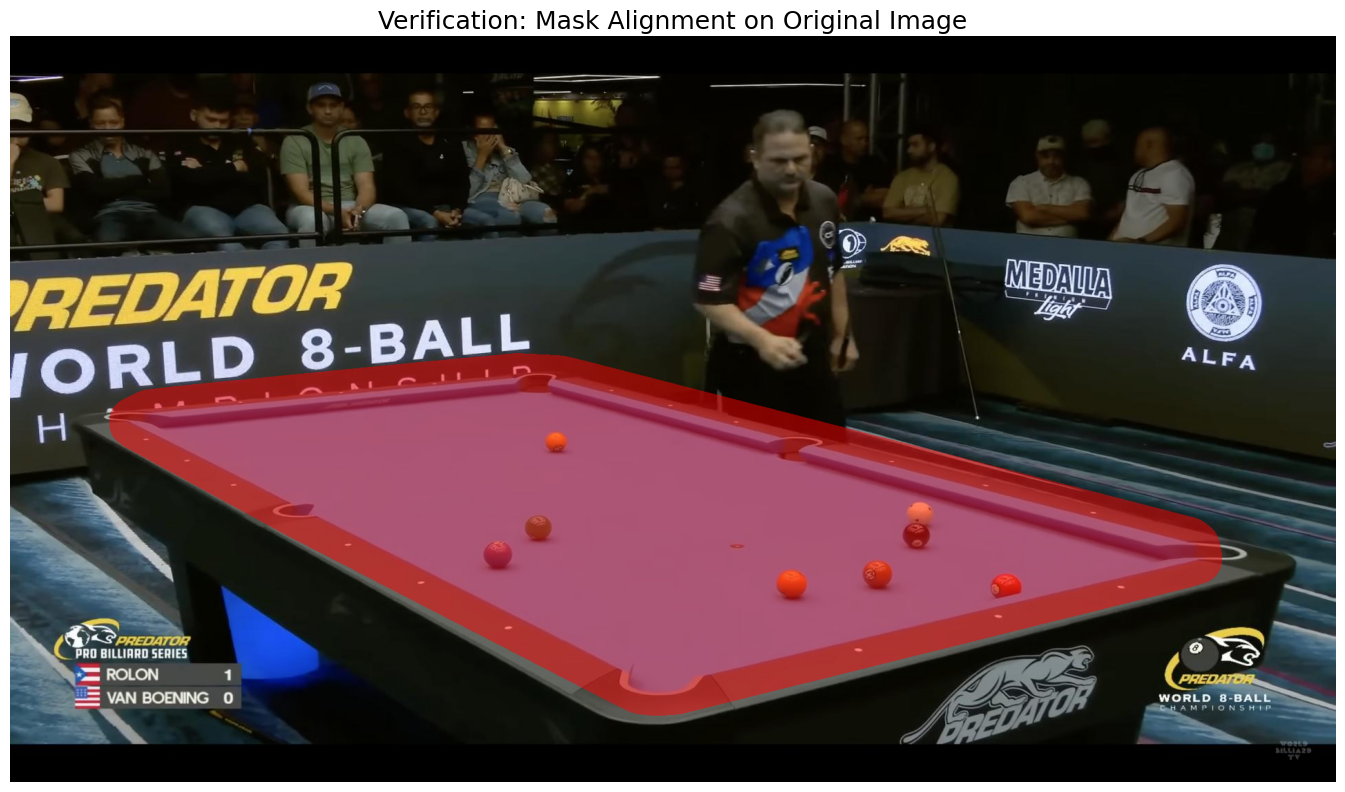

In [8]:
# Red Verification Overlay 
red_layer = np.zeros_like(test_img)
red_layer[:] = (255, 0, 0) 

blended_img = cv2.addWeighted(test_img, 0.5, red_layer, 0.5, 0)

overlay_img = np.where(final_mask[..., None] == 255, blended_img, test_img)

plt.figure(figsize=(14, 8))
plt.imshow(overlay_img)
plt.title("Verification: Mask Alignment on Original Image", fontsize=18, color='black')
plt.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Table Corner Extraction
Because our table mask has slightly rounded corners, we cannot simply look for the "tips" of the shape. Instead, this function finds the four straight sides of the table, draws mathematically perfect lines through them, and calculates exactly where those lines cross to find the true, sharp corners.

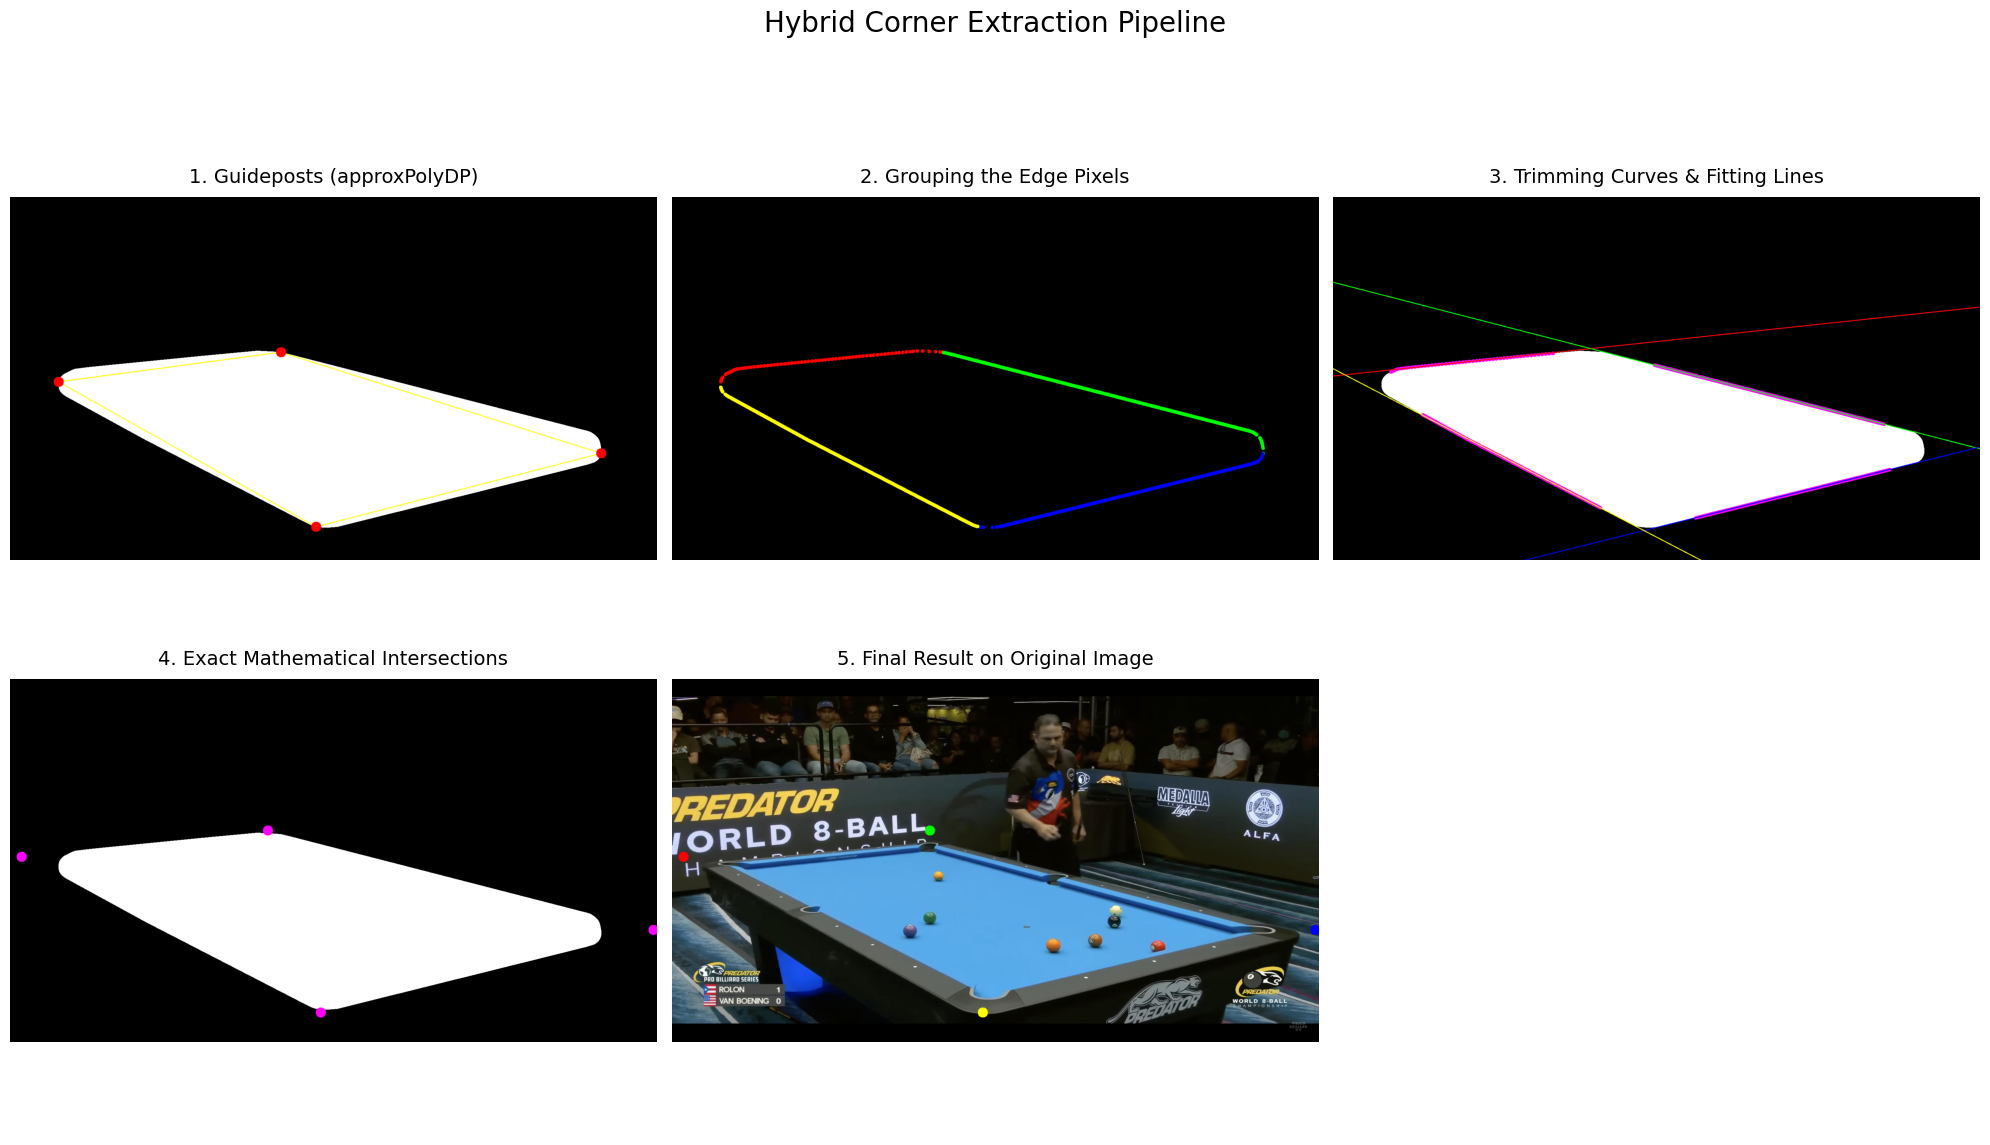

In [9]:
# ═══════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════

# Sorts corners using the center point as reference 
def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

# Line intersection function (returns a point if possible, None if parallel)
def intersect_lines(l1, l2):
    vx1, vy1, x1, y1 = l1
    vx2, vy2, x2, y2 = l2
    
    A1, B1 = vy1, -vx1
    C1 = vy1 * x1 - vx1 * y1
    
    A2, B2 = vy2, -vx2
    C2 = vy2 * x2 - vx2 * y2
    
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-6:
        return None 
        
    x = (C1 * B2 - C2 * B1) / det
    y = (A1 * C2 - A2 * C1) / det
    return [x, y]

def draw_infinite_line(img, line, color, thickness=2):
    vx, vy, x, y = line
    mult = 3000
    p1 = (int(x - mult * vx), int(y - mult * vy))
    p2 = (int(x + mult * vx), int(y + mult * vy))
    cv2.line(img, p1, p2, color, thickness)

corner_steps = {}

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None
    
    # Order the guideposts: 0:TL, 1:TR, 2:BR, 3:BL
    ordered_guides = order_points_clockwise(guide_corners)
    
    # Image 1: Show guideposts on the mask
    step1_img = mask_rgb.copy()
    cv2.polylines(step1_img, [np.int32(ordered_guides)], True, (255, 255, 0), 2)
    for pt in ordered_guides:
        cv2.circle(step1_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 0), -1)
    corner_steps['1_guideposts'] = step1_img


    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    # Assign every pixel to one of the 4 edges
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
    
    # Image 2: Show edge pixels colored by assigned edge
    step2_img = np.zeros_like(mask_rgb)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i in range(4):
        for pt in edge_points[i]:
            cv2.circle(step2_img, tuple(pt), 5, colors[i], -1)
    corner_steps['2_edge_pixels'] = step2_img


    # Fit a line to each edge
    fitted_lines = []
    step3_img = mask_rgb.copy()
    
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None
        
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
        for pt in ep_trimmed:
            cv2.circle(step3_img, tuple(pt), 5, (255, 0, 255), -1)
            
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        line = (vx[0], vy[0], x[0], y[0])
        fitted_lines.append(line)
        
        draw_infinite_line(step3_img, line, colors[i], 2)
        
    # Image 3: Show fitted lines on the mask
    corner_steps['3_fitted_lines'] = step3_img

    # Intersect the 4 lines to get the new corners
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) # Top intersects Left
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) # Top intersects Right
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) # Right intersects Bottom
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) # Bottom intersects Left
    
    if None in (tl, tr, br, bl): return None
    
    step4_img = mask_rgb.copy()

    final_corners = np.array([tl, tr, br, bl], dtype="float32")
    
    for pt in final_corners:
        cv2.circle(step4_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 255), -1)
    corner_steps['4_intersections'] = step4_img

    return final_corners



#  Run the Visualization

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)
    
    final_display_img = test_img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i, pt in enumerate(ordered_corners):
        cv2.circle(final_display_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel() 
    
    titles = [
        "1. Guideposts (approxPolyDP)", 
        "2. Grouping the Edge Pixels", 
        "3. Trimming Curves & Fitting Lines", 
        "4. Exact Mathematical Intersections",
        "5. Final Result on Original Image"
    ]
    
    images_to_show = [
        corner_steps['1_guideposts'], 
        corner_steps['2_edge_pixels'], 
        corner_steps['3_fitted_lines'], 
        corner_steps['4_intersections'],
        final_display_img
    ]
    
    for i in range(5):
        axes[i].imshow(images_to_show[i])
        axes[i].set_title(titles[i], color='black', fontsize=14, pad=10)
        axes[i].axis('off')

    axes[5].axis('off')

    plt.suptitle("Hybrid Corner Extraction Pipeline", fontsize=20, color='black')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Could not find corners to visualize.")

### 2.3 Table Warping Pipeline

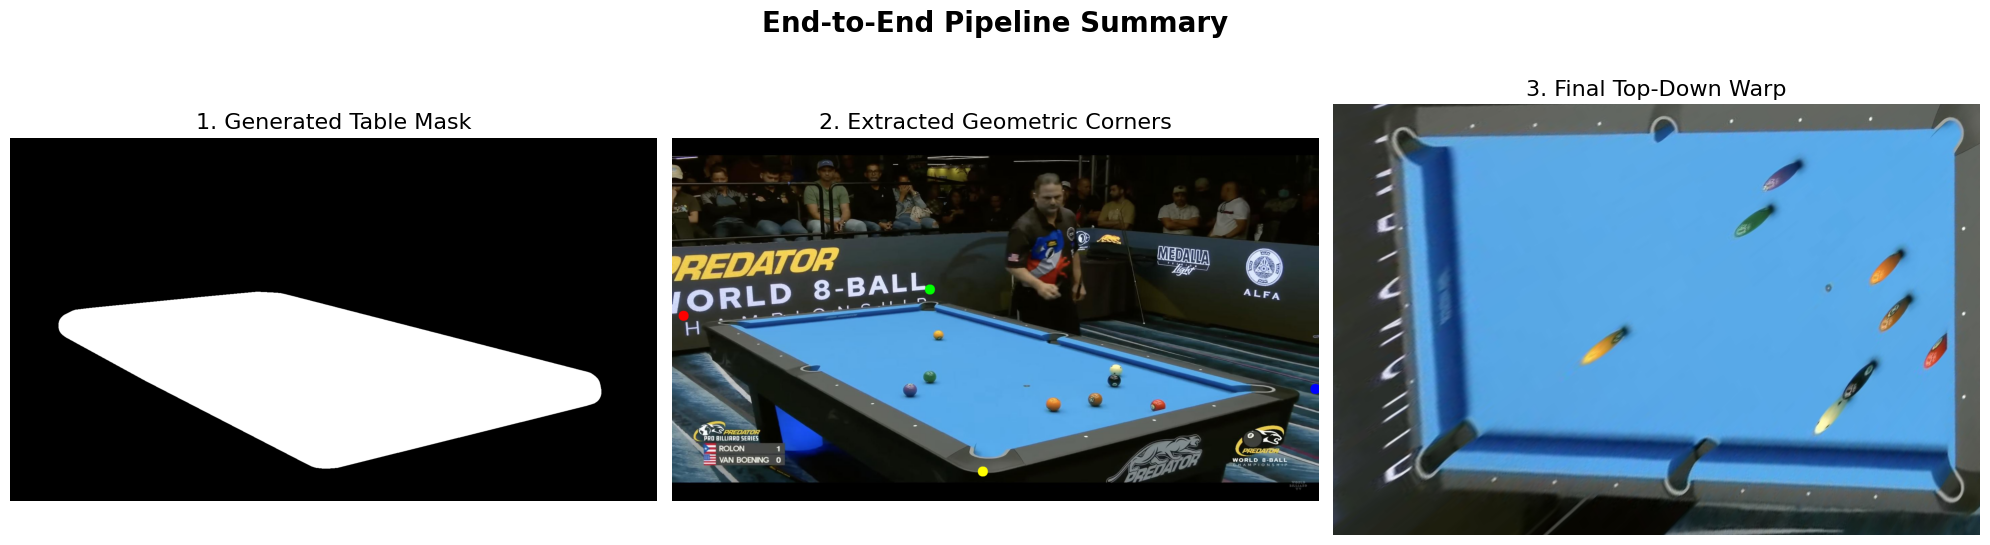

In [10]:
# Warps the 4 corners into an horizontal top-down view.
# Returns the warped image AND the transformation matrix (M) needed for backtracking.
def warp_to_top_down(image_rgb, ordered_corners, width=1200, height=800):
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    
    ratio = top_edge / left_edge
    
    if ratio < 1.8:
        # END-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [0, height - 1],         
            [width - 1, height - 1], 
            [width - 1, 0]           
        ], dtype="float32")
    else:
        # SIDE-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [width - 1, 0],          
            [width - 1, height - 1], 
            [0, height - 1]          
        ], dtype="float32")

    # M is the mathematical map from Original -> Flat
    M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)

    warped = cv2.warpPerspective(image_rgb, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    return warped, M

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)

corner_img = test_img.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
for i, pt in enumerate(ordered_corners):
    cv2.circle(corner_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
warped_img, warped_Mtx = warp_to_top_down(test_img, ordered_corners)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.imshow(test_mask, cmap='gray')
ax1.set_title("1. Generated Table Mask", fontsize=16, color='black')
ax1.axis('off')

ax2.imshow(corner_img)
ax2.set_title("2. Extracted Geometric Corners", fontsize=16, color='black')
ax2.axis('off')

ax3.imshow(warped_img)
ax3.set_title("3. Final Top-Down Warp", fontsize=16, color='black')
ax3.axis('off')

plt.suptitle("End-to-End Pipeline Summary", fontsize=20, weight='bold', color='black')
plt.tight_layout()
plt.show()

### 2.4 Save Table Warping Images

In [11]:
save_outputs = False

if save_outputs:
    # Save warped images
    output_folder = "output"
    os.makedirs(output_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{output_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    for filename, img_rgb in loaded_images.items():
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            ordered_corners = order_points_clockwise(raw_corners)
            
            warped_img, M = warp_to_top_down(img_rgb, ordered_corners)
            
            homography_matrices[filename] = M
            
            warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
            save_path = os.path.join(output_folder, filename)
            cv2.imwrite(save_path, warped_bgr)
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

Estimated table hue: 103


(np.float64(-0.5), np.float64(1199.5), np.float64(799.5), np.float64(-0.5))

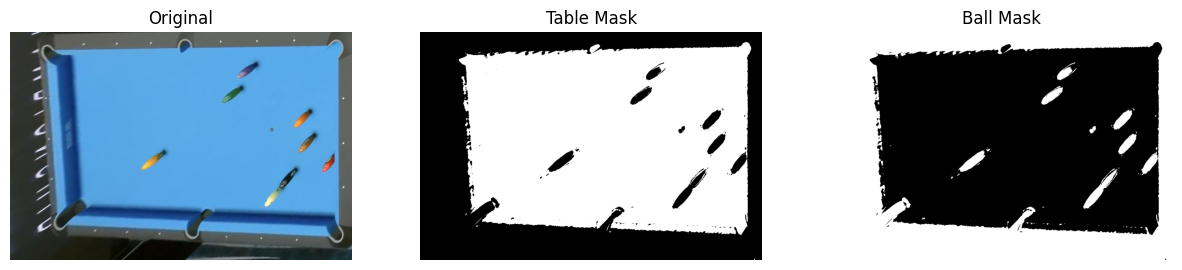

In [12]:
#test_img = loaded_images[test_key]

hsv = cv2.cvtColor(warped_img, cv2.COLOR_RGB2HSV)

h = hsv[:,:,0]
s = hsv[:,:,1]

# ignore low saturation (white areas, reflections)
mask = s > 60

table_h = int(np.median(h[mask]))

print("Estimated table hue:", table_h)

tolerance = 10

lower = np.array([table_h - tolerance, 150, 50])
upper = np.array([table_h + tolerance, 255, 255])

table_mask = cv2.inRange(hsv, lower, upper)
ball_mask = cv2.bitwise_not(table_mask)


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(warped_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(table_mask, cmap="gray")
plt.title("Table Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ball_mask, cmap="gray")
plt.title("Ball Mask")
plt.axis("off")

Estimated table hue: 103


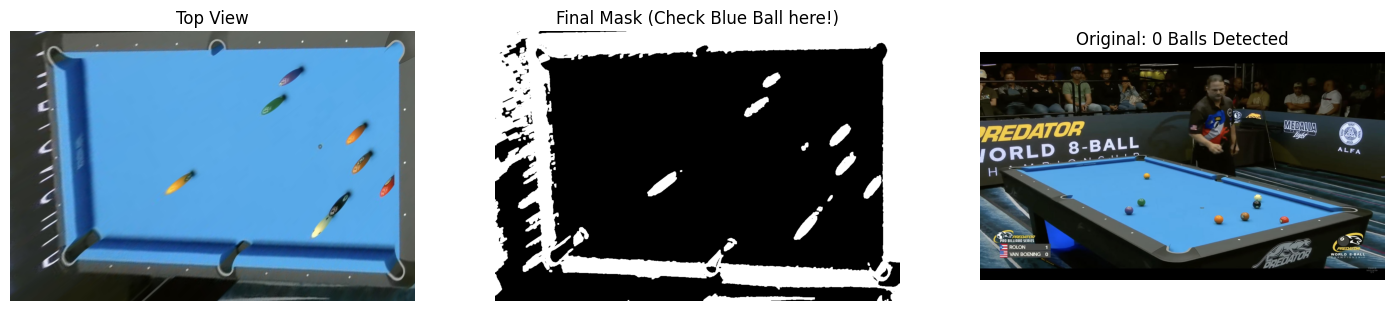

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_billiard_refined(img_orig, img_top, H):
    # Ensure H is a float64 matrix for precision
    H = np.array(H, dtype=np.float64)
    H_inv = np.linalg.inv(H)
    
    # --- 1. IMPROVED MASKING (Catching the Blue Ball) ---
    hsv_top = cv2.cvtColor(img_top, cv2.COLOR_RGB2HSV)

    h = hsv_top[:,:,0]
    s = hsv_top[:,:,1]

    # ignore low saturation (white areas, reflections)
    mask = s > 60

    table_h = int(np.median(h[mask]))

    print("Estimated table hue:", table_h)

    tolerance = 10

    lower_table = np.array([table_h - tolerance, 150, 50])
    upper_table = np.array([table_h + tolerance, 255, 255])
    
    table_mask = cv2.inRange(hsv_top, lower_table, upper_table)
    
    # Objects are everything NOT the table
    mask_inv = cv2.bitwise_not(table_mask)
    
    # REFINEMENT: Remove dark holes by brightness
    # Holes in the top view are usually very dark (low Value)
    _, brightness_mask = cv2.threshold(hsv_top[:,:,2], 50, 255, cv2.THRESH_BINARY)
    mask_inv = cv2.bitwise_and(mask_inv, brightness_mask)

    # Clean noise
    kernel = np.ones((5,5), np.uint8)
    mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_OPEN, kernel)

    # --- 2. FIND CONTOURS ---
    contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    balls = []
    h_top, w_top = img_top.shape[:2]
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 80 < area < 2500:
            # Circularity check
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0: continue
            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            
            if circularity > 0.55: # Loosened for the blue ball which might blend slightly
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    
                    # Margin check (Hole rejection)
                    margin = 40
                    if margin < cx < (w_top - margin) and margin < cy < (h_top - margin):
                        balls.append((cx, cy))

    # --- 3. MAPPING & DEBUGGING ---
    output_img = img_orig.copy()
    h_orig, w_orig = img_orig.shape[:2]
    
    for (cx, cy) in balls:
        # PROJECT POINT
        pt = np.array([cx, cy, 1.0], dtype=np.float64).reshape(3, 1)
        res = np.dot(H_inv, pt)
        
        # PERSPECTIVE DIVISION
        pix_x = int(res[0][0] / res[2][0])
        pix_y = int(res[1][0] / res[2][0])
        
        # ONLY DRAW IF INSIDE IMAGE BOUNDS
        if 0 <= pix_x < w_orig and 0 <= pix_y < h_orig:
            # Compensation for ball height (move box up 10 pixels)
            cv2.rectangle(output_img, (pix_x-20, pix_y-30), (pix_x+20, pix_y+10), (0, 255, 0), 3)
            # Draw center for verification
            cv2.circle(output_img, (pix_x, pix_y), 3, (255, 0, 0), -1)

    # --- VISUALIZATION ---
    plt.figure(figsize=(24, 6))
    
    plt.subplot(1, 4, 1)
    plt.imshow(img_top)
    plt.title("Top View")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(mask_inv, cmap='gray')
    plt.title("Final Mask (Check Blue Ball here!)")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(output_img)
    plt.title(f"Original: {len(balls)} Balls Detected")
    plt.axis('off')
    
    plt.show()

    cv2.imwrite("top.jpg", cv2.cvtColor(img_top, cv2.COLOR_RGB2BGR))
    cv2.imwrite("mask.jpg", cv2.cvtColor(mask_inv, cv2.COLOR_RGB2BGR))
    cv2.imwrite("out.jpg", cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))


# Run it
process_billiard_refined(test_img, warped_img, warped_Mtx)

Auto-Detected Table - Hue: 103.0, Sat: 156.0, Val: 227.0
10


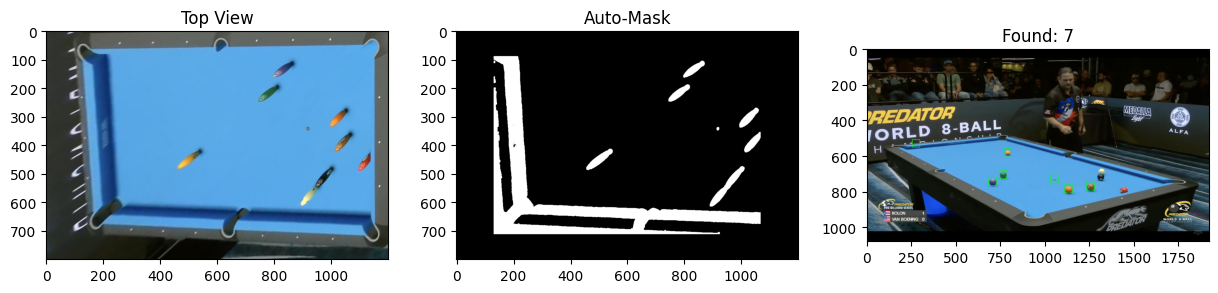

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_inner_table_mask(img_top, shrink_factor=0.05):
    """
    Creates a mask that stays inside the cushions based on the image dimensions.
    shrink_factor: 0.05 means moving 5% inward from each edge.
    """
    h, w = img_top.shape[:2]
    
    # Calculate margins based on a percentage of width/height
    # This is more "intelligent" than hardcoded pixels because it scales with resolution
    offset_w = int(w * shrink_factor)
    offset_h = int(h * shrink_factor)
    
    # Define the polygon for the playing surface (inner cloth)
    # This specifically targets the area inside the rails seen in top.jpg
    inner_pts = np.array([
        [offset_w, offset_h],           # Top-left
        [w - offset_w, offset_h],       # Top-right
        [w - offset_w, h - offset_h],   # Bottom-right
        [offset_w, h - offset_h]        # Bottom-left
    ], np.int32)
    
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [inner_pts], 255)
    
    return mask

def process_billiard_auto(img_orig, img_top, H):
    H = np.array(H, dtype=np.float64)
    H_inv = np.linalg.inv(H)

    inner_mask = get_inner_table_mask(img_top, shrink_factor=0.11)
    
    # --- 1. AUTO-CALIBRATE TABLE COLOR ---
    hsv_top = cv2.cvtColor(img_top, cv2.COLOR_RGB2HSV)
    
    # We take the median of the entire image 
    # (Assuming the cloth takes up >60% of the pixels)
    median_hsv = np.median(hsv_top.reshape(-1, 3), axis=0)
    m_h, m_s, m_v = median_hsv
    
    print(f"Auto-Detected Table - Hue: {m_h}, Sat: {m_s}, Val: {m_v}")

    # Define a tight tolerance around the median cloth color
    # This specifically removes the cloth but leaves the blue ball 
    # because the ball has different Saturation/Value than the flat cloth.
    lower_table = np.array([m_h - 10, m_s - 40, m_v - 60])
    upper_table = np.array([m_h + 10, 255, 255])
    
    table_mask = cv2.inRange(hsv_top, lower_table, upper_table)
    
    # Invert: Balls are now White
    mask_inv = cv2.bitwise_not(table_mask)

    mask_inv = cv2.bitwise_and(mask_inv, inner_mask)


    
    # --- 2. CLEANING & HOLE REJECTION ---
    # Remove dark pockets (Holes have very low Value/Brightness)
    #_, brightness_mask = cv2.threshold(hsv_top[:,:,2], 70, 255, cv2.THRESH_BINARY)
    #mask_inv = cv2.bitwise_and(mask_inv, brightness_mask)

    # Remove the table rails (They are usually darker or differently saturated)
    kernel = np.ones((5,5), np.uint8)
    mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_OPEN, kernel)
    
    '''
    dist_transform = cv2.distanceTransform(mask_inv, cv2.DIST_L2, 5)

    # 3. THRESHOLD THE DISTANCE
    # We only keep the "peaks" (the centers of the balls). 
    # If two balls touch, they will have two distinct peaks.
    # Adjust '0.5' to be higher (0.6) if balls are still merging, 
    # or lower (0.3) if you are losing small balls.
    ret, last_mask = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)
    last_mask = np.uint8(last_mask)
    '''
    # 4. FIND CONTOURS ON THE PEAKS
    # Now we find the centers of the balls rather than the whole ball
    contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(len(contours))


    balls = []
    h_top, w_top = img_top.shape[:2]
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 60 < area < 3000:
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0: continue
            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            
            # Lower circularity to 0.45 because your 'top.jpg' 
            # has very stretched ovals due to the homography angle
            if circularity > 0.3:
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
                    balls.append((cx, cy))

    # --- 4. DRAWING ---
    output = img_orig.copy()
    for (cx, cy) in balls:
        res = np.dot(H_inv, np.array([cx, cy, 1.0]))
        px, py = int(res[0]/res[2]), int(res[1]/res[2])
        
        if 0 <= px < output.shape[1] and 0 <= py < output.shape[0]:
            # Draw box (size scales slightly with perspective)
            s = int(18 + (py/150))
            cv2.rectangle(output, (px-s, py-s-5), (px+s, py+s-5), (0, 255, 0), 2)

    # Display results
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(img_top); plt.title("Top View")
    plt.subplot(1,3,2); plt.imshow(mask_inv, cmap='gray'); plt.title("Auto-Mask")
    plt.subplot(1,3,3); plt.imshow(output); plt.title(f"Found: {len(balls)}")
    plt.show()

    cv2.imwrite("mask.jpg", cv2.cvtColor(mask_inv, cv2.COLOR_RGB2BGR))
    cv2.imwrite("out.jpg", cv2.cvtColor(output, cv2.COLOR_RGB2BGR))


process_billiard_auto(test_img, warped_img, warped_Mtx)

Auto-Detected Table - Hue: 103.0, Sat: 156.0, Val: 227.0
10
Cluster found at (890, 474) with 3 distinct colors [28, 75, 96].
Cluster found at (457, 413) with 2 distinct colors [19, 102].
Cluster found at (1011, 354) with 2 distinct colors [15, 102].
Cluster found at (994, 269) with 2 distinct colors [13, 103].
Cluster found at (745, 187) with 2 distinct colors [73, 102].
Cluster found at (797, 104) with 1 distinct colors [110].
Cluster found at (132, 88) with 7 distinct colors [13, 34, 55, 75, 96, 120, -1].


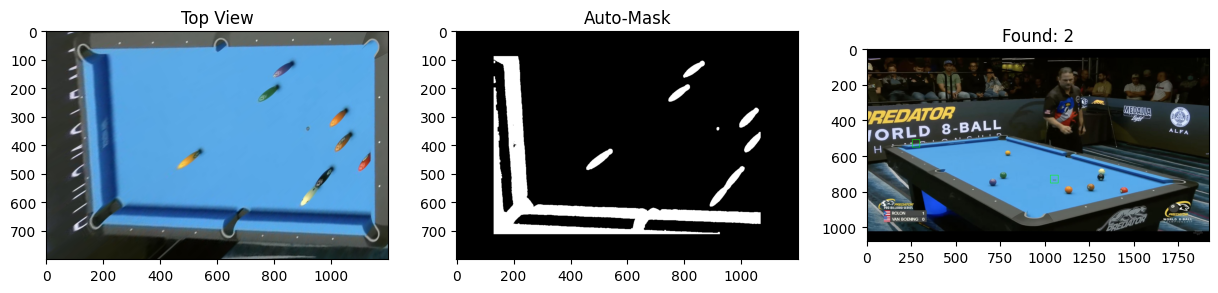

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_inner_table_mask(img_top, shrink_factor=0.05):
    """
    Creates a mask that stays inside the cushions based on the image dimensions.
    shrink_factor: 0.05 means moving 5% inward from each edge.
    """
    h, w = img_top.shape[:2]
    
    # Calculate margins based on a percentage of width/height
    # This is more "intelligent" than hardcoded pixels because it scales with resolution
    offset_w = int(w * shrink_factor)
    offset_h = int(h * shrink_factor)
    
    # Define the polygon for the playing surface (inner cloth)
    # This specifically targets the area inside the rails seen in top.jpg
    inner_pts = np.array([
        [offset_w, offset_h],           # Top-left
        [w - offset_w, offset_h],       # Top-right
        [w - offset_w, h - offset_h],   # Bottom-right
        [offset_w, h - offset_h]        # Bottom-left
    ], np.int32)
    
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [inner_pts], 255)
    
    return mask

def identify_colors_in_blob(roi_hsv, roi_mask):
    # 1. Calculate Hue Histogram only for the pixels inside the mask
    # Hue range is 0-180 in OpenCV
    hist = cv2.calcHist([roi_hsv], [0], roi_mask, [180], [0, 180])
    
    # Smooth the histogram to remove minor noise
    hist = cv2.GaussianBlur(hist, (5, 1), 0)
    
    # 2. Find Peaks (Unique Colors)
    # A peak exists if a value is higher than its neighbors 
    # and above a certain threshold (e.g., 50 pixels)
    peaks = []
    for i in range(1, 179):
        if hist[i] > hist[i-1] and hist[i] > hist[i+1]:
            if hist[i] > 50: # Minimum pixel count to be considered a 'ball color'
                # Ensure peaks are separated (e.g., 20 degrees apart)
                if not any(abs(i - p) < 20 for p in peaks):
                    peaks.append(i)
    
    # 3. Handle the White/Cue Ball (Special Case)
    # White has very low saturation, so it doesn't show up well in Hue peaks
    white_pixels = cv2.countNonZero(cv2.inRange(roi_hsv, (0, 0, 200), (180, 40, 255)))
    if white_pixels > 200: # If enough white/grey pixels exist
        peaks.append(-1) # Mark -1 as 'White/Striped'
        
    return len(peaks), peaks

def process_billiard_auto(img_orig, img_top, H):
    H = np.array(H, dtype=np.float64)
    H_inv = np.linalg.inv(H)

    inner_mask = get_inner_table_mask(img_top, shrink_factor=0.11)
    
    # --- 1. AUTO-CALIBRATE TABLE COLOR ---
    hsv_top = cv2.cvtColor(img_top, cv2.COLOR_RGB2HSV)
    
    # We take the median of the entire image 
    # (Assuming the cloth takes up >60% of the pixels)
    median_hsv = np.median(hsv_top.reshape(-1, 3), axis=0)
    m_h, m_s, m_v = median_hsv
    
    print(f"Auto-Detected Table - Hue: {m_h}, Sat: {m_s}, Val: {m_v}")

    # Define a tight tolerance around the median cloth color
    # This specifically removes the cloth but leaves the blue ball 
    # because the ball has different Saturation/Value than the flat cloth.
    lower_table = np.array([m_h - 10, m_s - 40, m_v - 60])
    upper_table = np.array([m_h + 10, 255, 255])
    
    table_mask = cv2.inRange(hsv_top, lower_table, upper_table)
    
    # Invert: Balls are now White
    mask_inv = cv2.bitwise_not(table_mask)

    mask_inv = cv2.bitwise_and(mask_inv, inner_mask)


    
    # --- 2. CLEANING & HOLE REJECTION ---
    # Remove dark pockets (Holes have very low Value/Brightness)
    #_, brightness_mask = cv2.threshold(hsv_top[:,:,2], 70, 255, cv2.THRESH_BINARY)
    #mask_inv = cv2.bitwise_and(mask_inv, brightness_mask)

    # Remove the table rails (They are usually darker or differently saturated)
    kernel = np.ones((5,5), np.uint8)
    mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_OPEN, kernel)
    
    '''
    dist_transform = cv2.distanceTransform(mask_inv, cv2.DIST_L2, 5)

    # 3. THRESHOLD THE DISTANCE
    # We only keep the "peaks" (the centers of the balls). 
    # If two balls touch, they will have two distinct peaks.
    # Adjust '0.5' to be higher (0.6) if balls are still merging, 
    # or lower (0.3) if you are losing small balls.
    ret, last_mask = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)
    last_mask = np.uint8(last_mask)
    '''
    # 4. FIND CONTOURS ON THE PEAKS
    # Now we find the centers of the balls rather than the whole ball
    contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(len(contours))


    balls = []
    h_top, w_top = img_top.shape[:2]
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        '''
        if 60 < area < 3000:
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0: continue
            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            
            # Lower circularity to 0.45 because your 'top.jpg' 
            # has very stretched ovals due to the homography angle
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
                balls.append((cx, cy))
        '''
        x, y, w, h = cv2.boundingRect(cnt)
        
        # --- CASE 1: Likely a single ball ---
        if 80 < area < 700:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                balls.append((int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])))
        
        # --- CASE 2: A Cluster (Touching Balls) ---
        elif area >= 700:
            roi_hsv = hsv_top[y:y+h, x:x+w]            
            roi_mask = mask_inv[y:y+h, x:x+w]

            num_colors, color_list = identify_colors_in_blob(roi_hsv, roi_mask)
                
            print(f"Cluster found at {x,y} with {num_colors} distinct colors {color_list}.")
            

    # --- 4. DRAWING ---
    output = img_orig.copy()
    for (cx, cy) in balls:
        res = np.dot(H_inv, np.array([cx, cy, 1.0]))
        px, py = int(res[0]/res[2]), int(res[1]/res[2])
        
        if 0 <= px < output.shape[1] and 0 <= py < output.shape[0]:
            # Draw box (size scales slightly with perspective)
            s = int(18 + (py/150))
            cv2.rectangle(output, (px-s, py-s-5), (px+s, py+s-5), (0, 255, 0), 2)

    # Display results
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(img_top); plt.title("Top View")
    plt.subplot(1,3,2); plt.imshow(mask_inv, cmap='gray'); plt.title("Auto-Mask")
    plt.subplot(1,3,3); plt.imshow(output); plt.title(f"Found: {len(balls)}")
    plt.show()

    cv2.imwrite("mask.jpg", cv2.cvtColor(mask_inv, cv2.COLOR_RGB2BGR))
    cv2.imwrite("out.jpg", cv2.cvtColor(output, cv2.COLOR_RGB2BGR))


process_billiard_auto(test_img, warped_img, warped_Mtx)

Auto-Detected Table - Hue: 103.0, Sat: 156.0, Val: 227.0
9
Cluster found at (138, 94) with 1 distinct colors [108].


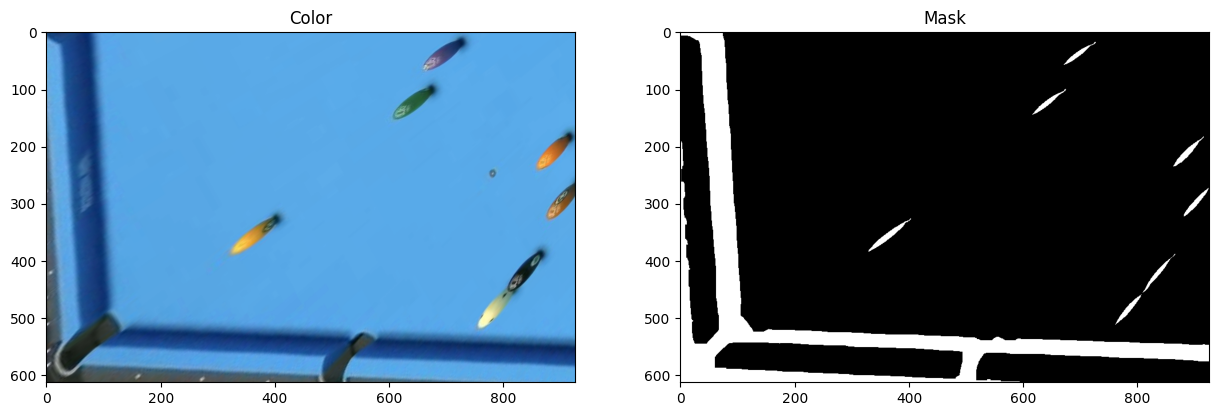

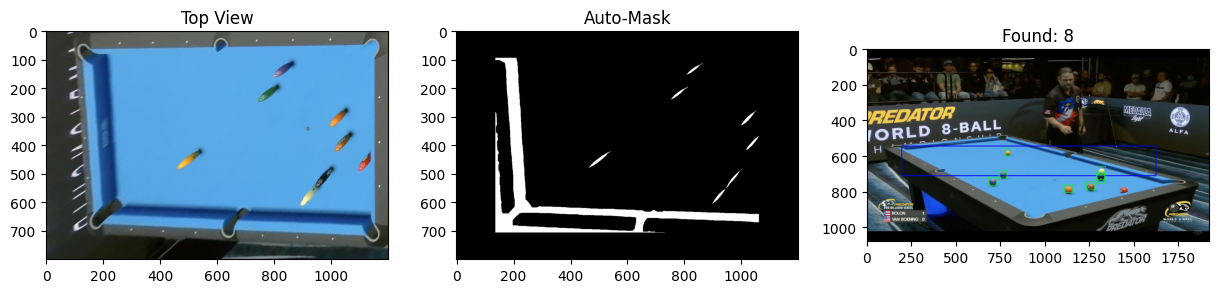

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_inner_table_mask(img_top, shrink_factor=0.05):
    """
    Creates a mask that stays inside the cushions based on the image dimensions.
    shrink_factor: 0.05 means moving 5% inward from each edge.
    """
    h, w = img_top.shape[:2]
    
    # Calculate margins based on a percentage of width/height
    # This is more "intelligent" than hardcoded pixels because it scales with resolution
    offset_w = int(w * shrink_factor)
    offset_h = int(h * shrink_factor)
    
    # Define the polygon for the playing surface (inner cloth)
    # This specifically targets the area inside the rails seen in top.jpg
    inner_pts = np.array([
        [offset_w, offset_h],           # Top-left
        [w - offset_w, offset_h],       # Top-right
        [w - offset_w, h - offset_h],   # Bottom-right
        [offset_w, h - offset_h]        # Bottom-left
    ], np.int32)
    
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [inner_pts], 255)
    
    return mask

def identify_colors_in_blob(roi_hsv, roi_mask):
    """
    roi_hsv: The HSV crop of the top view
    roi_mask: The crop of your ALREADY WORKING mask_inv
    """
    # 1. Use your mask to isolate the balls
    # 2. Inside that mask, only look at pixels with Saturation > 30
    # This ignores the 'blue-ish' blur at the edges of the balls
    color_cores = cv2.inRange(roi_hsv, (0, 30, 20), (180, 255, 255))
    final_processing_mask = cv2.bitwise_and(roi_mask, color_cores)

    # 3. Histogram of just the 'Vibrant' pixels
    hist = cv2.calcHist([roi_hsv], [0], final_processing_mask, [180], [0, 180])
    hist = cv2.GaussianBlur(hist, (5, 1), 0)
    
    peaks = []
    # If a peak is more than 10% of the vibrant pixels, it's a ball
    total_vibrant = np.sum(hist)
    if total_vibrant == 0: return 1, [0] # Fallback
    
    threshold = total_vibrant * 0.10

    for i in range(1, 179):
        if hist[i] > hist[i-1] and hist[i] > hist[i+1] and hist[i] > threshold:
            # Check for unique colors (Red/Orange/Purple)
            if not any(min(abs(i - p), 180 - abs(i - p)) < 12 for p in peaks):
                peaks.append(i)
    
    # 4. White Ball Check (High Brightness, Low Saturation)
    # We look for pixels inside your mask that ARE NOT vibrant
    white_pixels = cv2.bitwise_and(roi_mask, cv2.bitwise_not(color_cores))
    # Filter for high brightness (Value > 170)
    white_cores = cv2.bitwise_and(white_pixels, cv2.inRange(roi_hsv, (0, 0, 170), (180, 255, 255)))
    
    if cv2.countNonZero(white_cores) > (cv2.countNonZero(roi_mask) * 0.15):
        peaks.append(-1)
        
    return len(peaks), peaks

def process_billiard_auto(img_orig, img_top, H):
    H = np.array(H, dtype=np.float64)
    H_inv = np.linalg.inv(H)

    inner_mask = get_inner_table_mask(img_top, shrink_factor=0.11)
    
    # --- 1. AUTO-CALIBRATE TABLE COLOR ---
    hsv_top = cv2.cvtColor(img_top, cv2.COLOR_RGB2HSV)
    
    # We take the median of the entire image 
    # (Assuming the cloth takes up >60% of the pixels)
    median_hsv = np.median(hsv_top.reshape(-1, 3), axis=0)
    m_h, m_s, m_v = median_hsv
    
    print(f"Auto-Detected Table - Hue: {m_h}, Sat: {m_s}, Val: {m_v}")

    # Define a tight tolerance around the median cloth color
    # This specifically removes the cloth but leaves the blue ball 
    # because the ball has different Saturation/Value than the flat cloth.
    lower_table = np.array([m_h - 10, m_s - 40, m_v - 60])
    upper_table = np.array([m_h + 10, 255, 255])
    
    table_mask = cv2.inRange(hsv_top, lower_table, upper_table)
    
    # Invert: Balls are now White
    mask_inv = cv2.bitwise_not(table_mask)

    mask_inv = cv2.bitwise_and(mask_inv, inner_mask)


    # Remove the table rails (They are usually darker or differently saturated)
    kernel = np.ones((7,7), np.uint8)
    mask_inv = cv2.morphologyEx(mask_inv, cv2.MORPH_CLOSE, kernel)

    # A slightly larger kernel specifically for shrinking objects
    kernel = np.ones((7, 7), np.uint8)
    # Erode 'eats' the edges. 2 iterations will significantly separate touching balls.
    mask_inv = cv2.erode(mask_inv, kernel, iterations=2)


    # 4. FIND CONTOURS ON THE PEAKS
    # Now we find the centers of the balls rather than the whole ball
    contours, _ = cv2.findContours(mask_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(len(contours))


    balls = []
    h_top, w_top = img_top.shape[:2]
    base_ball_area = (h_top * w_top) * 0.0012

    output = img_orig.copy()

    
    for cnt in contours:
        area = cv2.contourArea(cnt)

        x, y, w, h = cv2.boundingRect(cnt)


        aspect_ratio = max(w, h) / min(w, h) if min(w, h) > 0 else 1

        # TRIGGER CLUSTER LOGIC IF:
        # 1. The area is significantly large (> 1.5 balls)
        # OR 2. The shape is very long (indicates 2 balls touching)
        is_cluster = (area > base_ball_area * 1.4) or (aspect_ratio > 1.6 and area > base_ball_area * 0.8)

        if not is_cluster:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                balls.append((int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])))
        
        # --- CASE 2: A Cluster (Touching Balls) ---
        else:
            # Inside the cluster 'else' block:
            roi_mask = mask_inv[y:y+h, x:x+w]
            roi_hsv = hsv_top[y:y+h, x:x+w]

            num_colors, color_list = identify_colors_in_blob(roi_hsv, roi_mask)
                
            print(f"Cluster found at {x,y} with {num_colors} distinct colors {color_list}.")

            # --- DRAWING FOR DEBUGGING ---
            # We transform the cluster's bounding box coordinates back to the original image
            # Top-left of cluster (x, y) -> Original Image (px1, py1)
            res1 = np.dot(H_inv, np.array([x, y, 1.0]))
            px1, py1 = int(res1[0]/res1[2]), int(res1[1]/res1[2])
            
            # Bottom-right of cluster (x+w, y+h) -> Original Image (px2, py2)
            res2 = np.dot(H_inv, np.array([x+w, y+h, 1.0]))
            px2, py2 = int(res2[0]/res2[2]), int(res2[1]/res2[2])

            # Draw a RED rectangle to indicate a detected cluster
            cv2.rectangle(output, (px1, py1), (px2, py2), (0, 0, 255), 3)
            
            
            plt.figure(figsize=(15, 5))
            plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(roi_hsv, cv2.COLOR_HSV2RGB)); plt.title("Color")
            plt.subplot(1,2,2); plt.imshow(roi_mask, cmap='gray'); plt.title("Mask")
            plt.show()


            #cv2.imwrite("see.jpg", cv2.cvtColor(roi_mask, cv2.COLOR_RGB2BGR))
            

    # --- 4. DRAWING ---
    for (cx, cy) in balls:
        res = np.dot(H_inv, np.array([cx, cy, 1.0]))
        px, py = int(res[0]/res[2]), int(res[1]/res[2])
        
        if 0 <= px < output.shape[1] and 0 <= py < output.shape[0]:
            # Draw box (size scales slightly with perspective)
            s = int(18 + (py/150))
            cv2.rectangle(output, (px-s, py-s-5), (px+s, py+s-5), (0, 255, 0), 2)

    # Display results
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(img_top); plt.title("Top View")
    plt.subplot(1,3,2); plt.imshow(mask_inv, cmap='gray'); plt.title("Auto-Mask")
    plt.subplot(1,3,3); plt.imshow(output); plt.title(f"Found: {len(balls)}")
    plt.show()

    cv2.imwrite("mask.jpg", cv2.cvtColor(mask_inv, cv2.COLOR_RGB2BGR))
    cv2.imwrite("out.jpg", cv2.cvtColor(output, cv2.COLOR_RGB2BGR))


process_billiard_auto(test_img, warped_img, warped_Mtx)

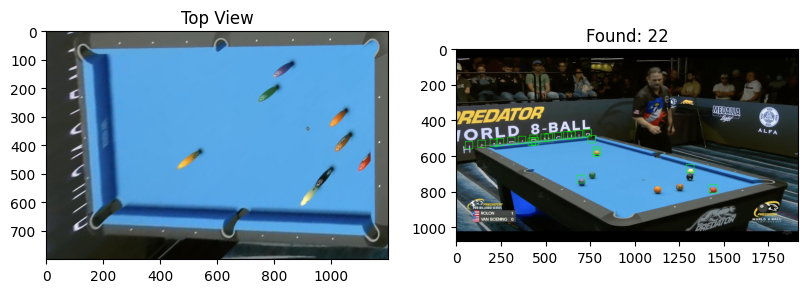

In [17]:
def process_by_color_islands(img_org, img_top, H):

    H_inv = np.linalg.inv(H)

    hsv = cv2.cvtColor(img_top, cv2.COLOR_RGB2HSV)
    
    # Define color ranges (Simplified examples)
    color_ranges = {
        'yellow': ([20, 100, 100], [30, 255, 255]),
        'red':    ([0, 100, 100], [10, 255, 255]),
        'blue':   ([100, 150, 50], [130, 255, 255]), # Strict for the ball
        'white':  ([0, 0, 180], [180, 50, 255])     # Low saturation, high value
    }
    
    all_balls = []
    
    for name, (low, high) in color_ranges.items():
        mask = cv2.inRange(hsv, np.array(low), np.array(high))
        
        # Now, even if a Red and Yellow ball touch, 
        # they are processed in different loops and won't merge!
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if 20 < cv2.contourArea(cnt) < 2000:
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    all_balls.append((int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])))

    output = img_org.copy()
    for (cx, cy) in all_balls:
        res = np.dot(H_inv, np.array([cx, cy, 1.0]))
        px, py = int(res[0]/res[2]), int(res[1]/res[2])
        
        if 0 <= px < output.shape[1] and 0 <= py < output.shape[0]:
            # Draw box (size scales slightly with perspective)
            s = int(18 + (py/150))
            cv2.rectangle(output, (px-s, py-s-5), (px+s, py+s-5), (0, 255, 0), 2)

    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(img_top); plt.title("Top View")
    plt.subplot(1,3,2); plt.imshow(output); plt.title(f"Found: {len(all_balls)}")
    plt.show()
    

process_by_color_islands(test_img,warped_img,warped_Mtx)

In [175]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, maximum_filter, gaussian_filter
import os

def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.025))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=3)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None

    return guide_corners


def remove_pockets_from_mask(balls_raw, ordered_corners, ball_r):
    # 1. Calculate the ratio of the top edge vs the left edge
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    ratio = top_edge / left_edge
    
    # 2. Define standard 2:1 pool table dimensions
    long_side = 2000
    short_side = 1000 
    
    balls_clean = balls_raw.copy()
    pocket_radii = [] # Store the calculated radius for each pocket
    
    # ─────────────────────────────────────────────────────────
    # CASE A: END-VIEW (Deep Perspective) -> ratio < 1.8
    # ─────────────────────────────────────────────────────────
    # ─────────────────────────────────────────────────────────
    # CASE A: END-VIEW (Deep Perspective) -> ratio < 1.8
    # ─────────────────────────────────────────────────────────
    if ratio < 1.8:
        w, h = short_side, long_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [0, h/2], [w, h/2]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply NON-LINEAR sizing based on Y-coordinate (Depth)
        min_y = np.min(image_pockets[:, 1])
        max_y = np.max(image_pockets[:, 1])
        y_range = max(max_y - min_y, 1.0)
        
        min_mult = 1.35 # Furthest pockets at the top of the image
        max_mult = 2.0 # Closest pockets at the bottom of the image
        
        for px, py in image_pockets:
            # 't' is a normalized linear value between 0.0 and 1.0
            t = (py - min_y) / y_range
            
            # Apply an exponent to curve the scaling. 
            # A power of 2.0 or 2.5 forces the middle pockets to stay smaller.
            t_curved = t ** 2.5
            
            mult = min_mult + t_curved * (max_mult - min_mult)
            r = int(ball_r * mult)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)
            
    # ─────────────────────────────────────────────────────────
    # CASE B: SIDE-VIEW / TOP-DOWN (Flat) -> ratio >= 1.8
    # ─────────────────────────────────────────────────────────
    else:
        w, h = long_side, short_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [w/2, 0], [w/2, h]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply CONSTANT sizing (Minimal depth distortion)
        for px, py in image_pockets:
            r = int(ball_r * 3.2)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)
            
    return balls_clean, image_pockets, pocket_radii

def local_peaks(comp_mask, ball_r, min_frac=0.28):
    dist = cv2.distanceTransform(comp_mask, cv2.DIST_L2, 5)
    dist_s = gaussian_filter(dist.astype(np.float32), sigma=ball_r * 0.15)
    neigh = max(5, int(ball_r * 0.80))
    if neigh % 2 == 0: neigh += 1
    lm = (maximum_filter(dist_s, size=neigh) == dist_s) & (dist_s > ball_r * min_frac)
    lm_lab, nlm = label(lm)
    centers = []
    for pid in range(1, nlm + 1):
        ys, xs = np.where(lm_lab == pid)
        peak_val = dist_s[ys, xs].max()
        if peak_val < ball_r * 0.45 or peak_val > ball_r * 1.4:
                continue
        centers.append((float(xs.mean()), float(ys.mean())))
    return centers

def calibrate_ball_radius(balls_raw):

    n, labels, stats, _ = cv2.connectedComponentsWithStats(balls_raw)

    radii = []

    for i in range(1, n):

        area = stats[i, cv2.CC_STAT_AREA]

        # ignore tiny noise
        if area < 500:
            continue

        comp = (labels == i).astype(np.uint8) * 255

        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not cnts:
            continue

        cnt = cnts[0]

        perim = cv2.arcLength(cnt, True)

        if perim == 0:
            continue

        circ = 4 * np.pi * area / (perim * perim)

        # keep only circular shapes
        if circ < 0.65:
            continue

        # convert area → radius
        r = np.sqrt(area / np.pi)

        radii.append(r)

    if len(radii) == 0:
        return 38.0

    return float(np.median(radii))

# ═══════════════════════════════════════════════════════════════
#  2. Main Execution Pipeline
# ═══════════════════════════════════════════════════════════════

# Load Image (REPLACE WITH YOUR PATH)
def function_main(image_rgb):
    img_h, img_w = image_rgb.shape[:2]

    # --- A. HSV Cloth Mask ---
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    cy, cx = img_h // 2, img_w // 2
    patch = hsv[cy - img_h // 10 : cy + img_h // 10, cx - img_w // 5 : cx + img_w // 5]
    h_med, s_med, v_med = int(np.median(patch[:, :, 0])), int(np.median(patch[:, :, 1])), int(np.median(patch[:, :, 2]))

    cloth_mask = cv2.inRange(
        hsv,
        (max(0, h_med - 2), max(40, s_med - 60), max(80, v_med - 70)),
        (min(170, h_med + 2), 255, 255)
    )

    cnts, _ = cv2.findContours(cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    table_mask = np.zeros_like(cloth_mask)
    if cnts:
        hull = cv2.convexHull(max(cnts, key=cv2.contourArea))
        cv2.drawContours(table_mask, [hull], -1, 255, -1)

    balls_raw = cv2.bitwise_and(cv2.bitwise_not(cloth_mask), table_mask)

    ball_r = calibrate_ball_radius(balls_raw)

    table_mask_to_be_used = get_table_mask(image_rgb)
    raw_corners = get_corners_from_mask(table_mask_to_be_used)

    # Order the corners exactly how your homography expects them
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        balls_clean, image_pockets, pocket_radius = remove_pockets_from_mask(balls_raw, ordered_corners, ball_r)
    else:
        ordered_corners = None
        balls_clean = balls_raw.copy()
        
    # --- D. Component Ball Detection (on CLEANED mask) ---
    n0, lab0, stats0, cent0 = cv2.connectedComponentsWithStats(balls_clean)
    SINGLE_MAX = np.pi * ball_r ** 2 * 1.8 
    all_balls = []

    for i in range(1, n0):
        area, w, h = stats0[i, cv2.CC_STAT_AREA], stats0[i, cv2.CC_STAT_WIDTH], stats0[i, cv2.CC_STAT_HEIGHT]
        if area < 400: continue
        comp = (lab0 == i).astype(np.uint8) * 255
        dist_c = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
        dist_max, aspect = dist_c.max(), max(w, h) / (min(w, h) + 1)

        if aspect > 5 and dist_max < ball_r * 0.35: continue # Pure rail
        
        if area <= SINGLE_MAX and dist_max > ball_r * 0.25:
            cnts_c, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts_c:
                perim = cv2.arcLength(cnts_c[0], True)
                circ = 4 * np.pi * area / perim ** 2 if perim > 0 else 0
                if circ > 0.25:
                    all_balls.append((cent0[i][0], cent0[i][1]))
                    continue

        if dist_max > ball_r * 0.28:
            all_balls.extend(local_peaks(comp, ball_r, min_frac=0.28))\
            
    # Deduplicate
    unique = []
    for (x, y) in all_balls:
        if not any(np.hypot(x - ux, y - uy) < ball_r * 0.85 for ux, uy in unique):
            unique.append((x, y))
    all_balls = unique

    # ═══════════════════════════════════════════════════════════════
    #  Build Debug Images (Using pure OpenCV)
    # ═══════════════════════════════════════════════════════════════
    
    def add_title(img, text):
        """Helper to draw a black background bar with white text at the top of an image"""
        out = img.copy()
        cv2.rectangle(out, (0, 0), (out.shape[1], 40), (0, 0, 0), -1)
        cv2.putText(out, text, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        return out

    # Image 1: Table Mask & Found Corners 
    img_1_corners = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2BGR)
    if ordered_corners is not None:
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 255, 255)] # Blue, Green, Red, Yellow
        for i, pt in enumerate(ordered_corners):
            cv2.circle(img_1_corners, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    img_1_corners = add_title(img_1_corners, "1. Table Hull & Corners")

    # Image 2: Raw Mask 
    img_2_raw = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    img_2_raw = add_title(img_2_raw, "2. Raw Balls Mask (Pockets Visible)")

    # Image 3: Projected Pockets Overlay
    img_3_pockets = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    if len(image_pockets) > 0:
        for i, pos in enumerate(image_pockets):
            cv2.circle(img_3_pockets, (int(pos[0]), int(pos[1])), pocket_radius[i], (255, 0, 0), -1)
    img_3_pockets = add_title(img_3_pockets, "3. Projected Homography Pockets")

    # Image 4: Clean Mask 
    img_4_clean = cv2.cvtColor(balls_clean.copy(), cv2.COLOR_GRAY2BGR)
    img_4_clean = add_title(img_4_clean, "4. Cleaned Mask (Fed to Blob Detector)")

    # Image 5: Blob Components & Detected Peaks
    img_5_comp = np.zeros((*balls_clean.shape, 3), dtype=np.uint8)
    np.random.seed(42) 
    cmap = np.random.randint(0, 255, size=(max(n0, 2), 3), dtype=np.uint8)
    for i in range(1, n0):
        if stats0[i, cv2.CC_STAT_AREA] < 400: continue
        img_5_comp[lab0 == i] = cmap[i]
        
    for (bx, by) in all_balls:
        cv2.drawMarker(img_5_comp, (int(bx), int(by)), (255, 255, 255), cv2.MARKER_CROSS, 15, 3)
    img_5_comp = add_title(img_5_comp, "5. Components & Detected Peaks")

    # Image 6: Final Result
    img_6_result = image_rgb.copy()
    draw_r = int(ball_r) + 5
    for idx, (bx, by) in enumerate(all_balls, 1):
        cv2.circle(img_6_result, (int(bx), int(by)), draw_r, (0, 220, 255), 3)
    img_6_result = add_title(img_6_result, f"6. Final Detection: {len(all_balls)} balls")

    # ═══════════════════════════════════════════════════════════════
    #  Create the 6-Panel Output Grid
    # ═══════════════════════════════════════════════════════════════
    combined_h = img_h * 2
    combined_w = img_w * 3
    all_debug_images_together = np.zeros((combined_h, combined_w, 3), dtype=np.uint8)
    
    all_debug_images_together[0:img_h, 0:img_w] = img_1_corners
    all_debug_images_together[0:img_h, img_w:2*img_w] = img_2_raw
    all_debug_images_together[0:img_h, 2*img_w:3*img_w] = img_3_pockets
    all_debug_images_together[img_h:2*img_h, 0:img_w] = img_4_clean
    all_debug_images_together[img_h:2*img_h, img_w:2*img_w] = img_5_comp
    all_debug_images_together[img_h:2*img_h, 2*img_w:3*img_w] = img_6_result

    debug_images = {
        "1_corners": img_1_corners,
        "2_raw_mask": img_2_raw,
        "3_pockets": img_3_pockets,
        "4_clean_mask": img_4_clean,
        "5_components": img_5_comp,
        "6_final_result": img_6_result
    }

    return all_balls, debug_images, all_debug_images_together

In [176]:
save_outputs = True

if save_outputs:
    detection_folder = "3_pockets____"
    os.makedirs(detection_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{detection_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    for filename, img_rgb in loaded_images.items():
        #if filename != "4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg":
        #    continue
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            balls, debug_images, all_debug_images_together = function_main(img_rgb)
            save_path = os.path.join(detection_folder, filename)
            cv2.imwrite(save_path, cv2.cvtColor(all_debug_images_together, cv2.COLOR_RGB2BGR))
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

Starting batch process. Saving top-down images to '3_pockets____'...
Batch complete! Warped 50 images. (0 failed)
Successfully saved 0 matrices for backtracking.
